CATBOOST ДЛЯ ПРЕДСКАЗАНИЯ ПОЛОМОК ОБОРУДОВАНИЯ

1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ:
----------------------------------------
Размер исходных данных: (136429, 14)
Колонки: ['id', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

После очистки: (136429, 10)
Целевая переменная распределение:
  0 (No Failure): 134281 (98.4%)
  1 (Failure): 2148 (1.6%)

Удалили 'Product ID' (слишком много уникальных значений)


2. РАЗДЕЛЕНИЕ ДАННЫХ:
----------------------------------------
Тренировочная выборка: (109143, 9)
Валидационная выборка: (27286, 9)

Распределение классов в train:
  0: 107425 (98.4%)
  1: 1718 (1.6%)

Распределение классов в val:
  0: 26856 (98.4%)
  1: 430 (1.6%)


3. АНАЛИЗ ПРИЗНАКОВ:
----------------------------------------
Типы данных признаков:
  Air temperature [K]       float64    Уникальных значений: 95
  Process temperature [K]   float64    У

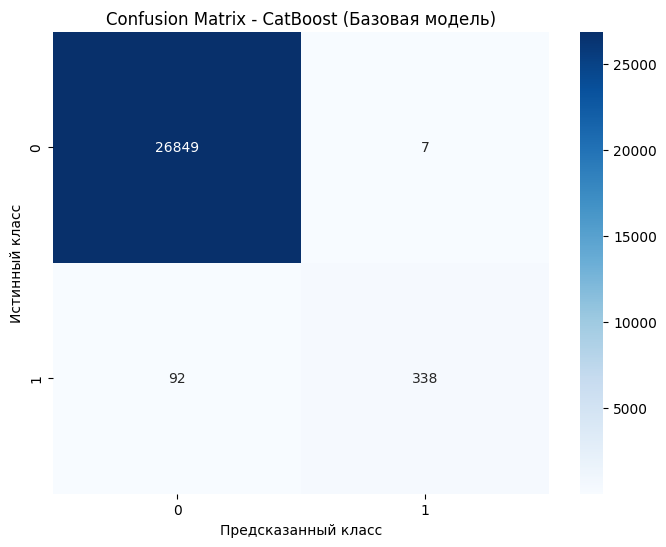



6. ВИЗУАЛИЗАЦИЯ ПРОЦЕССА ОБУЧЕНИЯ:
----------------------------------------


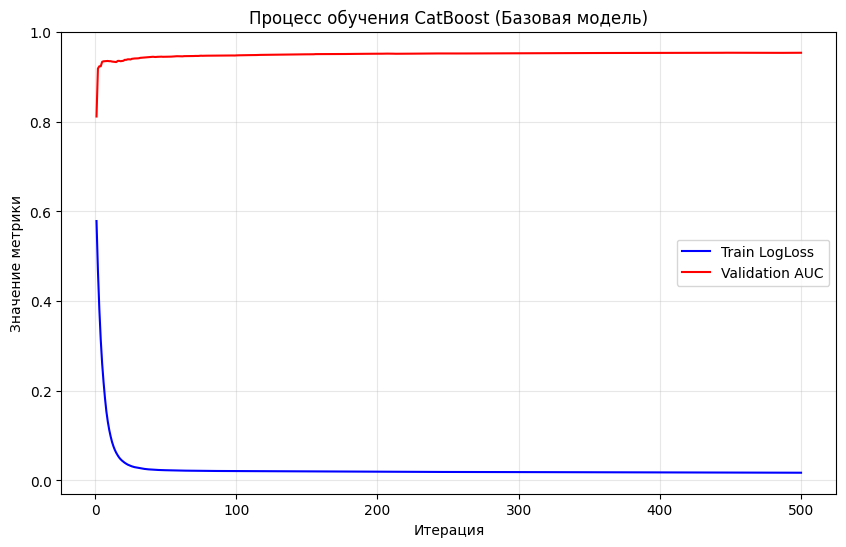



7. УЛУЧШЕННАЯ МОДЕЛЬ CATBOOST:
----------------------------------------
Начинаем обучение улучшенной модели...
0:	test: 0.9327732	best: 0.9327732 (0)	total: 31.6ms	remaining: 31.6s
100:	test: 0.9514587	best: 0.9514854 (98)	total: 2.95s	remaining: 26.3s
200:	test: 0.9516131	best: 0.9520958 (173)	total: 5.82s	remaining: 23.1s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9520957596
bestIteration = 173

Shrink model to first 174 iterations.

Метрики улучшенной модели:
Accuracy:  0.9637
Precision: 0.2831
Recall:    0.8512
F1-Score:  0.4248
ROC-AUC:   0.9521


8. КРОСС-ВАЛИДАЦИЯ CATBOOST:
----------------------------------------
Выполняем 5-кратную кросс-валидацию...
Training on fold [0/5]

bestTest = 0.9600631322
bestIteration = 189

Training on fold [1/5]

bestTest = 0.9684752342
bestIteration = 283

Training on fold [2/5]

bestTest = 0.9525898274
bestIteration = 261

Training on fold [3/5]

bestTest = 0.9702699219
bestIteration = 74

Training on fold [4/5]

bestT

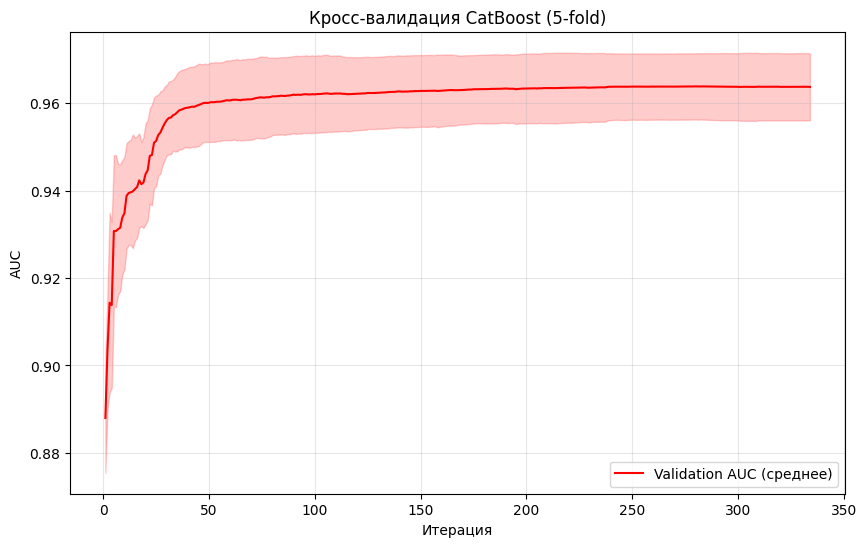



9. СРАВНЕНИЕ МОДЕЛЕЙ:
----------------------------------------

Таблица сравнения:
  Метрика  Базовая модель  Улучшенная модель  Изменение
 Accuracy        0.996372           0.963681  -0.032691
Precision        0.979710           0.283063  -0.696647
   Recall        0.786047           0.851163   0.065116
 F1-Score        0.872258           0.424840  -0.447418
  ROC-AUC        0.953970           0.952096  -0.001874


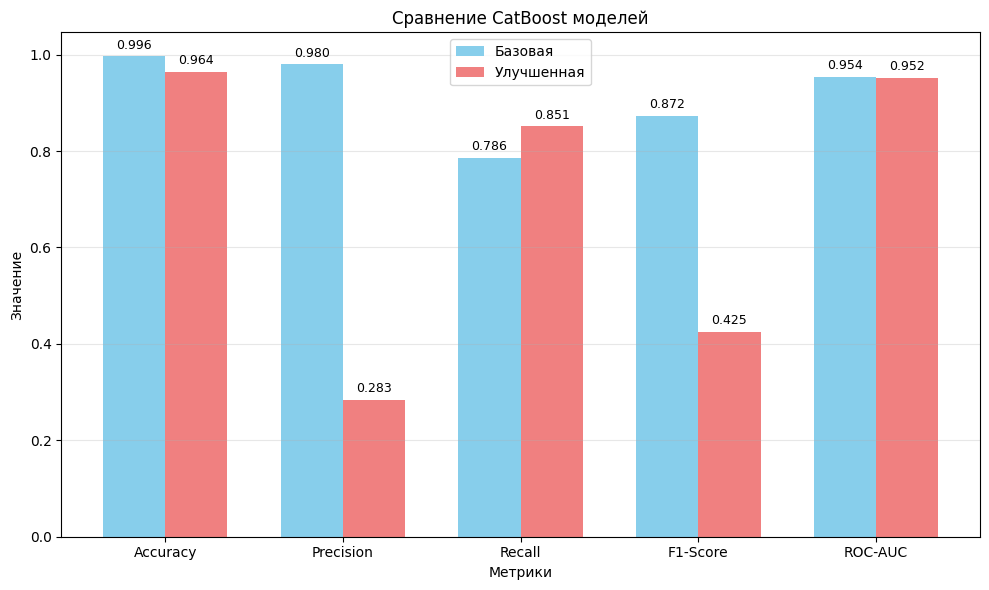



10. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ:
----------------------------------------

ТОП-10 важных признаков:
                feature  importance
                    HDF   25.401703
                    OSF   20.412031
                    PWF   15.677637
                    TWF   12.338873
            Torque [Nm]    6.627980
 Rotational speed [rpm]    5.951052
        Tool wear [min]    5.312446
    Air temperature [K]    4.884573
Process temperature [K]    3.393706


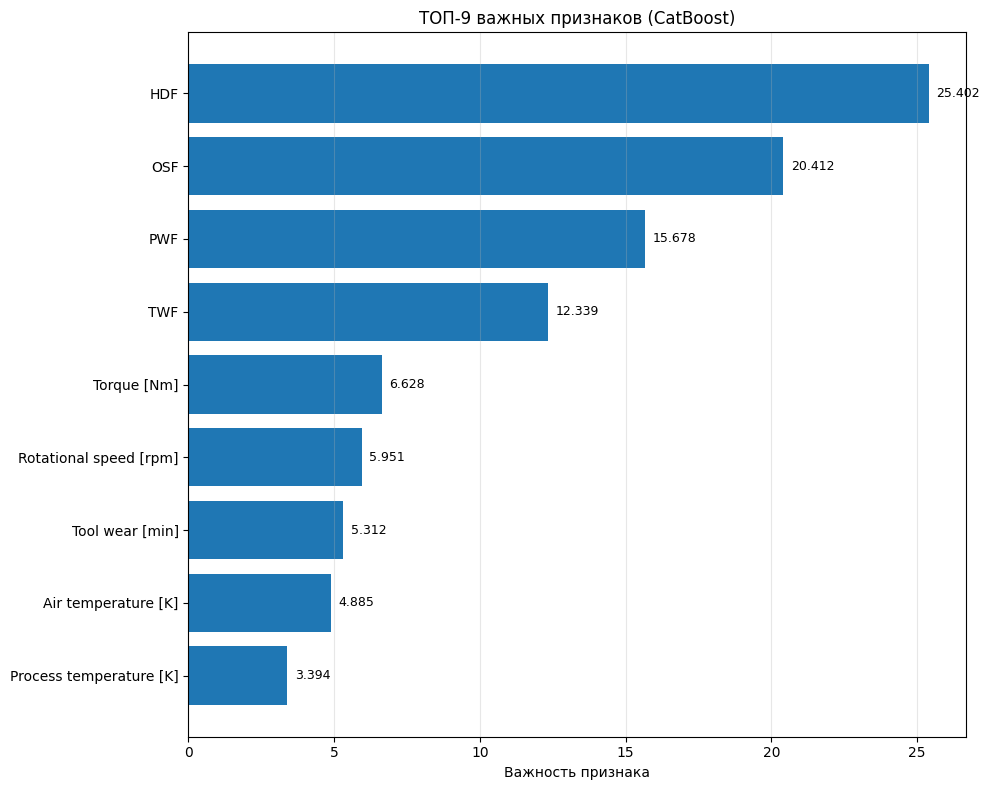



11. ROC-КРИВЫЕ:
----------------------------------------


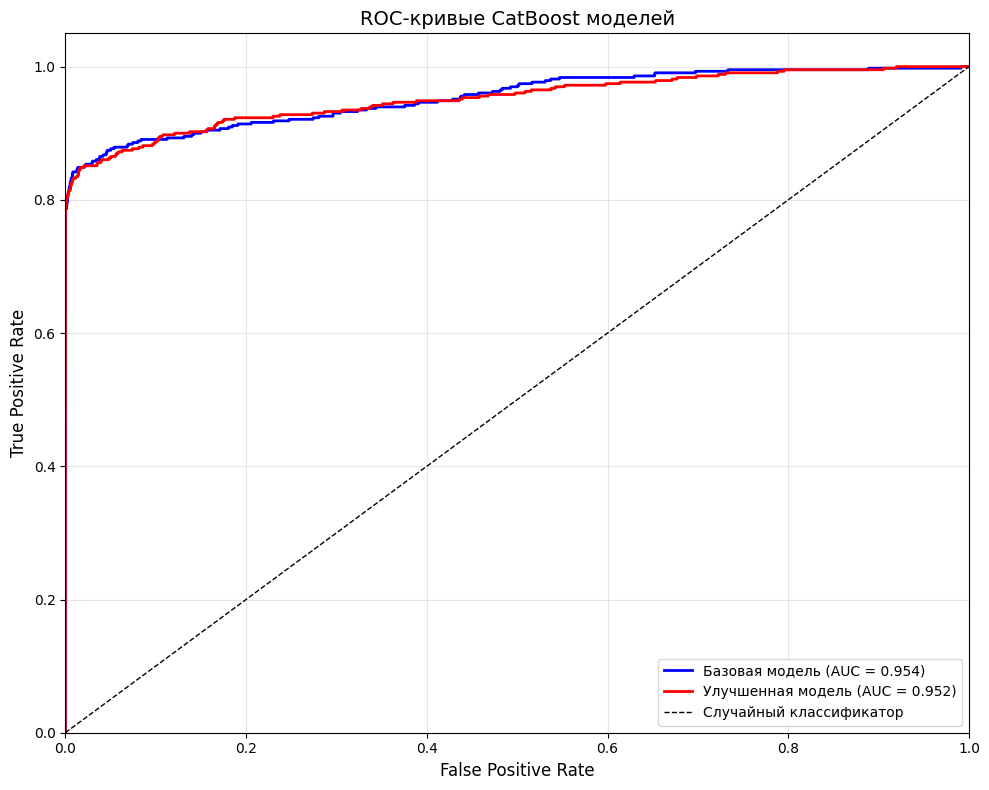



12. ПРОСТОЙ ТЮНИНГ ГИПЕРПАРАМЕТРОВ:
----------------------------------------

Комбинация 1: {'depth': 4, 'learning_rate': 0.1, 'l2_leaf_reg': 1}
  ROC-AUC: 0.9477

Комбинация 2: {'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 3}
  ROC-AUC: 0.9529

Комбинация 3: {'depth': 8, 'learning_rate': 0.03, 'l2_leaf_reg': 5}
  ROC-AUC: 0.9534

Комбинация 4: {'depth': 10, 'learning_rate': 0.01, 'l2_leaf_reg': 7}
  ROC-AUC: 0.9508

Лучшая комбинация: {'depth': 8, 'learning_rate': 0.03, 'l2_leaf_reg': 5}
Лучший ROC-AUC: 0.9534

Обучение финальной модели с лучшими параметрами...
0:	test: 0.8666436	best: 0.8666436 (0)	total: 29ms	remaining: 29s
100:	test: 0.9488449	best: 0.9488599 (92)	total: 2.67s	remaining: 23.8s
200:	test: 0.9520821	best: 0.9520821 (200)	total: 5.38s	remaining: 21.4s
300:	test: 0.9533554	best: 0.9534181 (290)	total: 8.04s	remaining: 18.7s
400:	test: 0.9540137	best: 0.9542302 (393)	total: 10.8s	remaining: 16.1s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 

In [10]:
# ===== ПОЛНЫЙ КОД ДЛЯ CATBOOST БЕЗ ВИЗУАЛИЗАЦИИ =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, roc_auc_score, 
                           classification_report, confusion_matrix, 
                           roc_curve, precision_score, recall_score, f1_score)
from catboost import CatBoostClassifier, Pool, cv
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("CATBOOST ДЛЯ ПРЕДСКАЗАНИЯ ПОЛОМОК ОБОРУДОВАНИЯ")
print("="*60)

# ===== 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ =====
print("\n1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ:")
print("-"*40)

url_train = "https://raw.githubusercontent.com/dvigatelizm/keis7/main/train.csv"
df = pd.read_csv(url_train)

print(f"Размер исходных данных: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")

# Удаляем ненужные колонки
drop_cols = ['id', 'RNF', 'Type']
df_clean = df.drop(columns=drop_cols)

# Разделяем на признаки и целевую переменную
X = df_clean.drop(columns=['Machine failure'])
y = df_clean['Machine failure']

print(f"\nПосле очистки: {X.shape}")
print(f"Целевая переменная распределение:")
print(f"  0 (No Failure): {sum(y == 0)} ({sum(y == 0)/len(y)*100:.1f}%)")
print(f"  1 (Failure): {sum(y == 1)} ({sum(y == 1)/len(y)*100:.1f}%)")

# Удаляем Product ID (слишком много уникальных значений)
if 'Product ID' in X.columns:
    X = X.drop(columns=['Product ID'])
    print("\nУдалили 'Product ID' (слишком много уникальных значений)")

# ===== 2. РАЗДЕЛЕНИЕ НА ТРЕНИРОВОЧНУЮ И ВАЛИДАЦИОННУЮ ВЫБОРКИ =====
print("\n\n2. РАЗДЕЛЕНИЕ ДАННЫХ:")
print("-"*40)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Сохраняем распределение классов
)

print(f"Тренировочная выборка: {X_train.shape}")
print(f"Валидационная выборка: {X_val.shape}")
print(f"\nРаспределение классов в train:")
print(f"  0: {sum(y_train == 0)} ({sum(y_train == 0)/len(y_train)*100:.1f}%)")
print(f"  1: {sum(y_train == 1)} ({sum(y_train == 1)/len(y_train)*100:.1f}%)")
print(f"\nРаспределение классов в val:")
print(f"  0: {sum(y_val == 0)} ({sum(y_val == 0)/len(y_val)*100:.1f}%)")
print(f"  1: {sum(y_val == 1)} ({sum(y_val == 1)/len(y_val)*100:.1f}%)")

# ===== 3. ОПРЕДЕЛЕНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ =====
print("\n\n3. АНАЛИЗ ПРИЗНАКОВ:")
print("-"*40)

# Определяем типы признаков
print("Типы данных признаков:")
for col in X_train.columns:
    dtype = X_train[col].dtype
    nunique = X_train[col].nunique()
    print(f"  {col:<25} {str(dtype):<10} Уникальных значений: {nunique}")

# Выбираем категориальные признаки
cat_features = []
for col in X_train.columns:
    # Если тип object или мало уникальных значений
    if X_train[col].dtype == 'object' or X_train[col].nunique() < 10:
        cat_features.append(col)

print(f"\nКатегориальные признаки ({len(cat_features)}): {cat_features}")

# Проверяем числовые признаки
numeric_features = [col for col in X_train.columns if col not in cat_features]
print(f"\nЧисловые признаки ({len(numeric_features)}): {numeric_features}")

# ===== 4. БАЗОВАЯ МОДЕЛЬ CATBOOST =====
print("\n\n4. ОБУЧЕНИЕ БАЗОВОЙ МОДЕЛИ CATBOOST:")
print("-"*40)

# Создаем Pool объекты (оптимизированный формат для CatBoost)
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

# Базовая модель с минимальными настройками
model_basic = CatBoostClassifier(
    iterations=500,            # Уменьшили для скорости
    learning_rate=0.05,        # Скорость обучения
    depth=6,                   # Глубина деревьев
    loss_function='Logloss',   # Функция потерь (для бинарной классификации)
    eval_metric='AUC',         # Метрика для валидации
    random_seed=42,
    verbose=100,               # Выводить логи каждые 100 итераций
    early_stopping_rounds=50,  # Ранняя остановка
    use_best_model=True,       # Использовать лучшую модель
    task_type='CPU'            # Использовать CPU
)

print("Начинаем обучение CatBoost...")
# Обучаем БЕЗ plot=True
model_basic.fit(
    train_pool,
    eval_set=val_pool
    # plot=True удалено, чтобы избежать ошибки с ipywidgets
)

# ===== 5. ОЦЕНКА БАЗОВОЙ МОДЕЛИ =====
print("\n\n5. ОЦЕНКА БАЗОВОЙ МОДЕЛИ:")
print("-"*40)

# Предсказания
y_pred_basic = model_basic.predict(X_val)
y_pred_proba_basic = model_basic.predict_proba(X_val)[:, 1]

# Метрики
accuracy_basic = accuracy_score(y_val, y_pred_basic)
precision_basic = precision_score(y_val, y_pred_basic)
recall_basic = recall_score(y_val, y_pred_basic)
f1_basic = f1_score(y_val, y_pred_basic)
roc_auc_basic = roc_auc_score(y_val, y_pred_proba_basic)

print(f"Accuracy:  {accuracy_basic:.4f}")
print(f"Precision: {precision_basic:.4f}")
print(f"Recall:    {recall_basic:.4f}")
print(f"F1-Score:  {f1_basic:.4f}")
print(f"ROC-AUC:   {roc_auc_basic:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred_basic))

# Матрица ошибок
cm_basic = confusion_matrix(y_val, y_pred_basic)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_basic, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - CatBoost (Базовая модель)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

# ===== 6. ВИЗУАЛИЗАЦИЯ ПРОЦЕССА ОБУЧЕНИЯ (ВРУЧНУЮ) =====
print("\n\n6. ВИЗУАЛИЗАЦИЯ ПРОЦЕССА ОБУЧЕНИЯ:")
print("-"*40)

# Получаем историю обучения
evals_result = model_basic.get_evals_result()

if evals_result and 'validation' in evals_result and 'AUC' in evals_result['validation']:
    train_auc = evals_result['learn']['Logloss'] if 'learn' in evals_result and 'Logloss' in evals_result['learn'] else None
    val_auc = evals_result['validation']['AUC']
    
    # Создаем график обучения
    plt.figure(figsize=(10, 6))
    
    if train_auc:
        plt.plot(range(1, len(train_auc) + 1), train_auc, 'b-', label='Train LogLoss')
    
    plt.plot(range(1, len(val_auc) + 1), val_auc, 'r-', label='Validation AUC')
    plt.xlabel('Итерация')
    plt.ylabel('Значение метрики')
    plt.title('Процесс обучения CatBoost (Базовая модель)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Не удалось получить историю обучения для визуализации")

# ===== 7. УЛУЧШЕННАЯ МОДЕЛЬ CATBOOST =====
print("\n\n7. УЛУЧШЕННАЯ МОДЕЛЬ CATBOOST:")
print("-"*40)

# Улучшенная модель с учетом дисбаланса классов
# УБИРАЕМ od_wait, используем только early_stopping_rounds
model_improved = CatBoostClassifier(
    iterations=1000,           # Увеличили количество итераций
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=3,                      # L2 регуляризация
    border_count=128,                   # Границы для числовых признаков
    random_strength=1,                  # Случайность в разбиениях
    bagging_temperature=0.8,            # Параметр бэггинга
    od_type='Iter',                     # Детекция переобучения
    # Убрали od_wait, используем только early_stopping_rounds
    loss_function='Logloss',
    eval_metric='AUC',
    scale_pos_weight=sum(y_train == 0) / sum(y_train == 1),  # Вес для дисбаланса
    random_seed=42,
    verbose=100,
    early_stopping_rounds=100,          # Ранняя остановка
    task_type='CPU'
)

print("Начинаем обучение улучшенной модели...")
model_improved.fit(
    train_pool,
    eval_set=val_pool
)

# Оценка улучшенной модели
y_pred_improved = model_improved.predict(X_val)
y_pred_proba_improved = model_improved.predict_proba(X_val)[:, 1]

accuracy_improved = accuracy_score(y_val, y_pred_improved)
precision_improved = precision_score(y_val, y_pred_improved)
recall_improved = recall_score(y_val, y_pred_improved)
f1_improved = f1_score(y_val, y_pred_improved)
roc_auc_improved = roc_auc_score(y_val, y_pred_proba_improved)

print(f"\nМетрики улучшенной модели:")
print(f"Accuracy:  {accuracy_improved:.4f}")
print(f"Precision: {precision_improved:.4f}")
print(f"Recall:    {recall_improved:.4f}")
print(f"F1-Score:  {f1_improved:.4f}")
print(f"ROC-AUC:   {roc_auc_improved:.4f}")

# ===== 8. КРОСС-ВАЛИДАЦИЯ =====
print("\n\n8. КРОСС-ВАЛИДАЦИЯ CATBOOST:")
print("-"*40)

# Параметры для кросс-валидации
cv_params = {
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 6,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'random_seed': 42,
    'verbose': False,
    'early_stopping_rounds': 50  # Добавляем early stopping для CV
}

print("Выполняем 5-кратную кросс-валидацию...")
cv_data = cv(
    params=cv_params,
    pool=train_pool,
    fold_count=5,
    shuffle=True,
    partition_random_seed=42,
    stratified=True,
    verbose=False
)

print(f"Лучший AUC на CV: {cv_data['test-AUC-mean'].max():.4f}")
print(f"Лучшая итерация: {cv_data['test-AUC-mean'].idxmax() + 1}")

# Визуализация результатов CV
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cv_data) + 1), cv_data['test-AUC-mean'], 'r-', label='Validation AUC (среднее)')
plt.fill_between(range(1, len(cv_data) + 1), 
                 cv_data['test-AUC-mean'] - cv_data['test-AUC-std'],
                 cv_data['test-AUC-mean'] + cv_data['test-AUC-std'],
                 alpha=0.2, color='red')
plt.xlabel('Итерация')
plt.ylabel('AUC')
plt.title('Кросс-валидация CatBoost (5-fold)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ===== 9. СРАВНЕНИЕ МОДЕЛЕЙ =====
print("\n\n9. СРАВНЕНИЕ МОДЕЛЕЙ:")
print("-"*40)

comparison = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Базовая модель': [accuracy_basic, precision_basic, recall_basic, f1_basic, roc_auc_basic],
    'Улучшенная модель': [accuracy_improved, precision_improved, recall_improved, f1_improved, roc_auc_improved],
    'Изменение': [
        accuracy_improved - accuracy_basic,
        precision_improved - precision_basic,
        recall_improved - recall_basic,
        f1_improved - f1_basic,
        roc_auc_improved - roc_auc_basic
    ]
})

print("\nТаблица сравнения:")
print(comparison.to_string(index=False))

# Визуализация сравнения
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison['Метрика']))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['Базовая модель'], width, label='Базовая', color='skyblue')
bars2 = ax.bar(x + width/2, comparison['Улучшенная модель'], width, label='Улучшенная', color='lightcoral')

ax.set_xlabel('Метрики')
ax.set_ylabel('Значение')
ax.set_title('Сравнение CatBoost моделей')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Метрика'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ===== 10. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ =====
print("\n\n10. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ:")
print("-"*40)

# Получаем важность признаков из улучшенной модели
feature_importance = model_improved.get_feature_importance()
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nТОП-10 важных признаков:")
print(importance_df.head(10).to_string(index=False))

# Визуализация важности признаков
plt.figure(figsize=(10, 8))
top_n = min(15, len(importance_df))
bars = plt.barh(range(top_n), importance_df['importance'].head(top_n)[::-1])
plt.yticks(range(top_n), importance_df['feature'].head(top_n)[::-1])
plt.xlabel('Важность признака')
plt.title(f'ТОП-{top_n} важных признаков (CatBoost)')
plt.grid(True, alpha=0.3, axis='x')

# Добавляем значения
for i, (bar, importance) in enumerate(zip(bars, importance_df['importance'].head(top_n)[::-1])):
    plt.text(importance + max(feature_importance)*0.01, bar.get_y() + bar.get_height()/2,
             f'{importance:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# ===== 11. ROC-КРИВЫЕ =====
print("\n\n11. ROC-КРИВЫЕ:")
print("-"*40)

# Вычисляем ROC-кривые
fpr_basic, tpr_basic, _ = roc_curve(y_val, y_pred_proba_basic)
fpr_improved, tpr_improved, _ = roc_curve(y_val, y_pred_proba_improved)

plt.figure(figsize=(10, 8))
plt.plot(fpr_basic, tpr_basic, 'b-', linewidth=2, 
         label=f'Базовая модель (AUC = {roc_auc_basic:.3f})')
plt.plot(fpr_improved, tpr_improved, 'r-', linewidth=2, 
         label=f'Улучшенная модель (AUC = {roc_auc_improved:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Случайный классификатор')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые CatBoost моделей', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

# ===== 12. ТЮНИНГ ГИПЕРПАРАМЕТРОВ =====
print("\n\n12. ПРОСТОЙ ТЮНИНГ ГИПЕРПАРАМЕТРОВ:")
print("-"*40)

# Простой поиск по сетке вручную
best_score = 0
best_params = {}

# Пробуем разные комбинации
param_combinations = [
    {'depth': 4, 'learning_rate': 0.1, 'l2_leaf_reg': 1},
    {'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 3},
    {'depth': 8, 'learning_rate': 0.03, 'l2_leaf_reg': 5},
    {'depth': 10, 'learning_rate': 0.01, 'l2_leaf_reg': 7},
]

for i, params in enumerate(param_combinations, 1):
    print(f"\nКомбинация {i}: {params}")
    
    model_tuned = CatBoostClassifier(
        iterations=300,
        **params,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=42,
        verbose=False,
        early_stopping_rounds=30
    )
    
    model_tuned.fit(train_pool, eval_set=val_pool)
    
    y_pred_tuned = model_tuned.predict(X_val)
    score = roc_auc_score(y_val, model_tuned.predict_proba(X_val)[:, 1])
    
    print(f"  ROC-AUC: {score:.4f}")
    
    if score > best_score:
        best_score = score
        best_params = params.copy()

print(f"\nЛучшая комбинация: {best_params}")
print(f"Лучший ROC-AUC: {best_score:.4f}")

# Обучаем финальную модель с лучшими параметрами
print("\nОбучение финальной модели с лучшими параметрами...")
final_model = CatBoostClassifier(
    iterations=1000,
    **best_params,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=100,
    task_type='CPU'
)

final_model.fit(train_pool, eval_set=val_pool)

# Оценка финальной модели
y_pred_final = final_model.predict(X_val)
y_pred_proba_final = final_model.predict_proba(X_val)[:, 1]

roc_auc_final = roc_auc_score(y_val, y_pred_proba_final)
print(f"\nФинальная модель ROC-AUC: {roc_auc_final:.4f}")

# ===== 13. СОХРАНЕНИЕ И ЗАГРУЗКА МОДЕЛИ =====
print("\n\n13. СОХРАНЕНИЕ МОДЕЛИ:")
print("-"*40)

# Определяем лучшую модель
scores = {
    'basic': roc_auc_basic,
    'improved': roc_auc_improved,
    'final': roc_auc_final
}
best_model_name = max(scores, key=scores.get)

if best_model_name == 'basic':
    best_model = model_basic
elif best_model_name == 'improved':
    best_model = model_improved
else:
    best_model = final_model

model_filename = 'best_catboost_model.cbm'
best_model.save_model(model_filename)
print(f"Лучшая модель ({best_model_name}) сохранена как '{model_filename}'")
print(f"ROC-AUC лучшей модели: {scores[best_model_name]:.4f}")

# Пример загрузки модели
print("\nПример загрузки модели:")
loaded_model = CatBoostClassifier()
loaded_model.load_model(model_filename)
print("Модель успешно загружена!")

# ===== 14. ПРЕДСКАЗАНИЯ НА НОВЫХ ДАННЫХ =====
print("\n\n14. ПРИМЕР ПРЕДСКАЗАНИЙ:")
print("-"*40)

# Берем несколько примеров из валидационной выборки
np.random.seed(42)
sample_indices = np.random.choice(len(X_val), min(5, len(X_val)), replace=False)
sample_X = X_val.iloc[sample_indices]
sample_y = y_val.iloc[sample_indices]

# Делаем предсказания
sample_predictions = best_model.predict(sample_X)
sample_probabilities = best_model.predict_proba(sample_X)[:, 1]

print("\nПримеры предсказаний:")
print("-" * 70)
print(f"{'Пример':<10} {'Истинный класс':<15} {'Предсказание':<15} {'Вероятность поломки':<20}")
print("-" * 70)
for i, idx in enumerate(sample_indices):
    true_class = sample_y.iloc[i]
    pred_class = sample_predictions[i]
    prob = sample_probabilities[i]
    print(f"{i+1:<10} {true_class:<15} {pred_class:<15} {prob:.3f}")
print("-" * 70)

# ===== 15. СРАВНЕНИЕ С DECISION TREE =====
print("\n\n15. СРАВНЕНИЕ С DECISION TREE:")
print("-"*40)

# Для сравнения обучим простой Decision Tree
from sklearn.tree import DecisionTreeClassifier

print("Обучаем Decision Tree для сравнения...")
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_val)
y_pred_proba_dt = dt_model.predict_proba(X_val)[:, 1]

roc_auc_dt = roc_auc_score(y_val, y_pred_proba_dt)
accuracy_dt = accuracy_score(y_val, y_pred_dt)

print(f"Decision Tree Results:")
print(f"  ROC-AUC: {roc_auc_dt:.4f}")
print(f"  Accuracy: {accuracy_dt:.4f}")

print(f"\nCatBoost Results:")
print(f"  ROC-AUC: {scores[best_model_name]:.4f}")
print(f"  Accuracy: {accuracy_score(y_val, best_model.predict(X_val)):.4f}")

improvement = ((scores[best_model_name] - roc_auc_dt) / roc_auc_dt) * 100
print(f"\nУлучшение CatBoost над Decision Tree: {improvement:+.1f}%")

# ===== 16. ВЫВОДЫ И РЕКОМЕНДАЦИИ =====
print("\n\n" + "="*60)
print("ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("="*60)

print(f"\n1. Результаты CatBoost:")
print(f"   Лучшая модель: {best_model_name}")
print(f"   ROC-AUC: {scores[best_model_name]:.4f}")
print(f"   Улучшение над Decision Tree: {improvement:+.1f}%")

print(f"\n2. Важные признаки (по CatBoost):")
for i, row in importance_df.head(5).iterrows():
    print(f"   {i+1}. {row['feature']}: {row['importance']:.3f}")

print(f"\n3. Лучшие параметры:")
print(f"   {best_params}")

print(f"\n4. Преимущества CatBoost:")
print("   - Автоматическая обработка категориальных признаков")
print("   - Встроенная защита от переобучения")
print("   - Хорошо работает с дисбалансом классов")
print("   - Высокое качество 'из коробки'")

print(f"\n5. Рекомендации:")
print("   - Использовать CatBoost для production")
print("   - Установить ipywidgets для визуализации: pip install ipywidgets")
print("   - Рассмотреть оптимизацию на GPU для больших данных")

print(f"\nCatBoost обучен успешно! ✅")
print(f"\nСводка:")
print(f"• Decision Tree ROC-AUC: {roc_auc_dt:.4f}")
print(f"• CatBoost ROC-AUC: {scores[best_model_name]:.4f}")
print(f"• Улучшение: {improvement:+.1f}%")